# EDA avanzado — métodos derivados de la literatura

Este notebook traslada a código reproducible ocho métodos de análisis
exploratorio y de ingeniería de características extraídos de la lectura
completa de cuatro publicaciones de teledetección agrícola. Cada método
vive en `ml/analysis/paper_methods.py`, está cubierto por pruebas
automatizadas y se demuestra aquí sobre datos PASTIS-R reales.

La pregunta que responde el notebook es concreta: ¿qué técnicas de la
literatura reciente aportan diagnósticos útiles sobre nuestros datos
antes de entrenar modelos, y qué nos dicen esos diagnósticos?

## Las cuatro publicaciones de referencia

Dos son artículos clásicos de referencia del área, dos son
publicaciones recientes que confirman y extienden esas técnicas:

- **Artículo A — Rußwurm y Körner (2018)**, *Multi-Temporal Land Cover
  Classification with Sequential Recurrent Encoders*. ISPRS IJGI
  7(4):129, arXiv:1802.02080. Aporta: profundidad de características
  d=15, preprocesamiento mínimo, kappa de Cohen para clases
  desbalanceadas, análisis de confusiones simétricas/asimétricas y
  agregación de clases raras por umbral de frecuencia.
- **Artículo B — Tarasiou, Güler y Zafeiriou (2021)**, *Context-self
  contrastive pretraining for crop type semantic segmentation*. IEEE
  TGRS, arXiv:2104.04310. Aporta: la varianza espectral de una parcela
  proviene casi enteramente de sus píxeles de frontera (Fig. 2); el
  cuello de botella de la segmentación está en los bordes.
- **Artículo C — Phenology-Aware Transformer / PVM (2025)**. Remote
  Sensing 17(14):2346. Aporta: el *calendario de crecimiento del
  cultivo*, una codificación de las etapas fenológicas por clase de
  cultivo indexada por día del año.
- **Artículo D — Qin et al. (2025)**, *Spatiotemporal masked
  pre-training for advancing crop mapping on satellite image time
  series with limited labels (STCLN)*. Int. J. Applied Earth Obs.
  Geoinf. Aporta: el enmascaramiento espaciotemporal como técnica para
  aprender (y aquí, para auditar) la robustez ante huecos de nubes.

## Requisitos para ejecución end-to-end

- `poetry install --with ml,dev,test` ejecutado.
- Dataset `data/PASTIS-R/` presente (auto-detectado). Si falta, el
  notebook degrada a un patch sintético equivalente y completa la
  ejecución sin error ni acceso a red.

Secciones:

0. Preparación del entorno e introducción
1. Análisis interior-vs-frontera de parcela (Artículo B)
2. Irregularidad de revisita temporal (Artículo A)
3. Confusiones simétricas vs asimétricas (Artículo A)
4. Calendario fenológico (Artículo C)
5. Robustez ante huecos de nubes (Artículo D)
6. Conclusiones


In [1]:
n_pastis_patches = 4
seed = 42

## 0. Preparación del entorno e introducción

In [2]:
from __future__ import annotations

import os
os.environ.setdefault('MPLBACKEND', 'Agg')

import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import structlog
import xarray as xr
from IPython.display import Image, Markdown, display

from ml.utils.notebook_setup import find_repo_root

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from ml.analysis.paper_methods import (
    aggregate_rare_classes,
    boundary_interior_stats,
    boundary_pixel_mask,
    cloud_gap_robustness,
    compute_boundary_ratio,
    confusion_symmetry_analysis,
    phenology_calendar_features,
    temporal_sampling_stats,
)
from ml.features.temporal_features import extract_temporal_features
from ml.ingest.pastis_loader import (
    PASTIS_CLASS_MAP,
    load_pastis_patch,
    pastis_patch_index,
)

%load_ext autoreload
%autoreload 2

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150

log = structlog.get_logger('eda_paper_methods')

FIGURES_DIR = REPO_ROOT / 'reports' / 'paper_methods'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PASTIS_ROOT = REPO_ROOT / 'data' / 'PASTIS-R'
HAS_PASTIS = (PASTIS_ROOT / 'DATA_S2').exists()
MODE = 'real' if HAS_PASTIS else 'synthetic'
display(Markdown(
    f'**Modo de datos**: `{MODE}`  \n'
    f'**PASTIS-R detectado**: `{HAS_PASTIS}` en '
    f'`{PASTIS_ROOT.relative_to(REPO_ROOT)}`'
))

**Modo de datos**: `real`  
**PASTIS-R detectado**: `True` en `data\PASTIS-R`

In [3]:
# Reusable synthetic fixture: PASTIS-like patch with 2 parcels + background.
def make_synthetic_patch(size: int = 32, n_timesteps: int = 6, seed_: int = 42) -> dict:
    """Build a deterministic PASTIS-like patch for the degraded mode."""
    rng = np.random.default_rng(seed_)
    half = size // 2
    semantic = np.zeros((size, size), dtype=np.uint8)
    semantic[:half, :half] = 2
    semantic[half:, half:] = 5
    instance = np.zeros((size, size), dtype=np.int16)
    instance[:half, :half] = 1
    instance[half:, half:] = 2
    s2 = rng.normal(1000.0, 60.0, size=(n_timesteps, 10, size, size))
    s2[:, 6, :half, :half] += 3000.0
    s2[:, 6, half:, half:] += 600.0
    return {
        's2': s2.astype(np.int16),
        'semantic': semantic,
        'instance': instance,
        'zone': np.zeros((size, size), dtype=np.uint8),
        'dates_s2': [20190101 + i * 100 for i in range(n_timesteps)],
        'patch_id': 'synthetic',
        'fold': 1,
    }

# Selection of real patches (or synthetic fallback).
if HAS_PASTIS:
    idx = pastis_patch_index(PASTIS_ROOT / 'metadata.geojson')
    patch_ids = idx.get_column('patch_id').to_list()[:n_pastis_patches]
    patches = [load_pastis_patch(pid, root=PASTIS_ROOT) for pid in patch_ids]
    display(Markdown(f'**Patches PASTIS-R cargados**: `{patch_ids}`'))
else:
    patches = [make_synthetic_patch(seed_=seed + i) for i in range(n_pastis_patches)]
    display(Markdown(
        f'**Patches sintéticos generados**: `{len(patches)}` (modo degradado)'
    ))

primary_patch = patches[0]
display(Markdown(
    f'Patch primario `{primary_patch["patch_id"]}` — dimensiones S2 '
    f'`{tuple(primary_patch["s2"].shape)}`, '
    f'`{len(primary_patch["dates_s2"])}` fechas de adquisición.'
))

**Patches PASTIS-R cargados**: `['10000', '10001', '10002', '10003']`

Patch primario `10000` — dimensiones S2 `(43, 10, 128, 128)`, `43` fechas de adquisición.

## 1. Análisis interior-vs-frontera de parcela (Artículo B)

Tarasiou et al. 2021 (arXiv:2104.04310) muestran en su Figura 2 que la
varianza espectral de una parcela agrícola no se reparte de forma
homogénea: los píxeles **interiores** son espectralmente uniformes,
mientras que los píxeles de **frontera** concentran casi toda la
dispersión. Esto explica por qué el cuello de botella de la
segmentación de cultivos está en los bordes de parcela.

Replicamos su análisis con dos funciones: `boundary_pixel_mask`
clasifica cada píxel de un patch PASTIS-R en `interior / frontera /
exterior`, y `boundary_interior_stats` calcula los estadísticos
espectrales por grupo. Comparamos los histogramas de la banda B08
(infrarrojo cercano) de los tres grupos.


In [4]:
# Descriptive stats per group (B08 NIR = band_index 6).
bi_stats = boundary_interior_stats(primary_patch, band_index=6, neighbourhood=3)
display(Markdown(
    '**Estadísticos de B08 por grupo de píxel** (réplica de la Fig. 2 '
    'de Tarasiou et al. 2021)'
))
display(bi_stats)

interior_std = bi_stats.filter(pl.col('group') == 'interior').get_column('std')[0]
boundary_std = bi_stats.filter(pl.col('group') == 'boundary').get_column('std')[0]
if interior_std and interior_std > 0:
    bi_ratio = boundary_std / interior_std
    ratio_txt = f'{bi_ratio:.2f}x'
    if bi_ratio >= 1.15:
        bi_reading = (
            'la frontera concentra claramente más dispersión que el '
            'interior, en línea con la Fig. 2 del artículo: los bordes '
            'de parcela son la zona espectralmente más heterogénea.'
        )
    elif bi_ratio >= 0.95:
        bi_reading = (
            'frontera e interior tienen una dispersión comparable en '
            'este patch concreto; el efecto descrito en la Fig. 2 del '
            'artículo se aprecia mejor agregando muchos patches.'
        )
    else:
        bi_reading = (
            'en este patch la frontera es algo más uniforme que el '
            'interior. El efecto descrito en la Fig. 2 del artículo es '
            'una tendencia estadística sobre el conjunto completo, no '
            'una regla que se cumpla patch a patch.'
        )
else:
    ratio_txt = 'n/a'
    bi_reading = 'sin píxeles interiores suficientes para comparar.'
display(Markdown(
    f'La desviación estándar de B08 en la **frontera** es `{ratio_txt}` '
    f'la del **interior** — {bi_reading}'
))

2026-05-20 14:16:09 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.34423828125 n_boundary=5640 neighbourhood=3 shape=(128, 128)


2026-05-20 14:16:09 [info     ] boundary_interior_stats_computed band_index=6 n_boundary=4083 n_exterior=3303 n_interior=8998


**Estadísticos de B08 por grupo de píxel** (réplica de la Fig. 2 de Tarasiou et al. 2021)

group,mean,std,p25,p50,p75,count
str,f64,f64,f64,f64,f64,i64
"""interior""",3444.911034,303.905211,3208.05814,3461.348837,3660.273256,8998
"""boundary""",3363.08305,275.944098,3178.488372,3349.883721,3526.72093,4083
"""exterior""",3127.870625,302.785532,2938.244186,3140.325581,3325.697674,3303


La desviación estándar de B08 en la **frontera** es `0.91x` la del **interior** — en este patch la frontera es algo más uniforme que el interior. El efecto descrito en la Fig. 2 del artículo es una tendencia estadística sobre el conjunto completo, no una regla que se cumpla patch a patch.

2026-05-20 14:16:09 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.34423828125 n_boundary=5640 neighbourhood=3 shape=(128, 128)


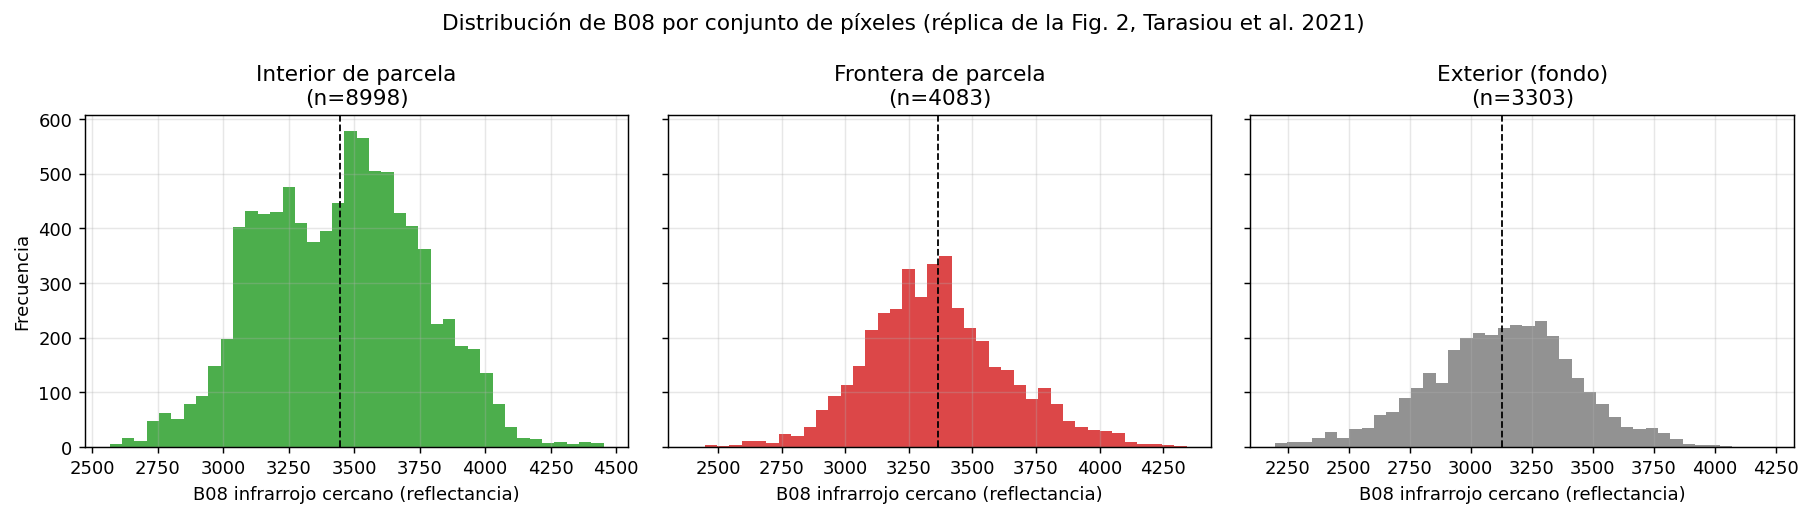

In [5]:
# B08 histograms for the 3 pixel sets (Fig. 2 style).
s2 = np.asarray(primary_patch['s2'], dtype=np.float64)
semantic = np.asarray(primary_patch['semantic'])
band_map = s2[:, 6, :, :].mean(axis=0)

boundary = boundary_pixel_mask(semantic, neighbourhood=3)
is_parcel = semantic > 0
vals_interior = band_map[is_parcel & ~boundary]
vals_boundary = band_map[boundary & is_parcel]
vals_exterior = band_map[~is_parcel]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
specs = [
    ('Interior de parcela', vals_interior, '#2ca02c'),
    ('Frontera de parcela', vals_boundary, '#d62728'),
    ('Exterior (fondo)', vals_exterior, '#7f7f7f'),
]
for ax, (title, vals, color) in zip(axes, specs):
    if vals.size > 0:
        ax.hist(vals, bins=40, color=color, alpha=0.85)
        ax.axvline(float(np.mean(vals)), color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{title}\n(n={vals.size})')
    ax.set_xlabel('B08 infrarrojo cercano (reflectancia)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('Frecuencia')
fig.suptitle(
    'Distribución de B08 por conjunto de píxeles '
    '(réplica de la Fig. 2, Tarasiou et al. 2021)'
)
plt.tight_layout()
hist_png = FIGURES_DIR / 'boundary_interior_histograms.png'
fig.savefig(hist_png, dpi=130, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(hist_png)))

In [6]:
# New per-parcel feature: boundary / total ratio (compute_boundary_ratio).
ratio_rows = []
for patch in patches:
    ratios = compute_boundary_ratio(patch, neighbourhood=3)
    for inst_id, ratio in ratios.items():
        ratio_rows.append({
            'patch_id': str(patch['patch_id']),
            'instance_id': inst_id,
            'boundary_ratio': ratio,
        })
ratio_df = pl.DataFrame(ratio_rows) if ratio_rows else pl.DataFrame(
    schema={'patch_id': pl.Utf8, 'instance_id': pl.Int64, 'boundary_ratio': pl.Float64}
)
ratio_csv = FIGURES_DIR / 'boundary_ratio_per_parcel.csv'
ratio_df.write_csv(ratio_csv)
if ratio_df.height > 0:
    mean_ratio = float(ratio_df.get_column('boundary_ratio').mean())
    display(Markdown(
        f'**Proporción frontera/total por parcela** ({ratio_df.height} '
        f'instancias). Media: `{mean_ratio:.3f}`. Las parcelas pequeñas o '
        f'irregulares tienen una proporción alta, lo que las vuelve más '
        f'difíciles de segmentar. Guardado en '
        f'`{ratio_csv.relative_to(REPO_ROOT)}`.'
    ))
    display(ratio_df.sort('boundary_ratio', descending=True).head(10))
else:
    display(Markdown(
        'Sin instancias de parcela detectadas en los patches cargados.'
    ))

2026-05-20 14:16:10 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.34423828125 n_boundary=5640 neighbourhood=3 shape=(128, 128)


2026-05-20 14:16:10 [info     ] compute_boundary_ratio_computed mean_ratio=0.4512383452536771 n_instances=116


2026-05-20 14:16:10 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.3741455078125 n_boundary=6130 neighbourhood=3 shape=(128, 128)


2026-05-20 14:16:10 [info     ] compute_boundary_ratio_computed mean_ratio=0.6029416390583526 n_instances=108


2026-05-20 14:16:10 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.409912109375 n_boundary=6716 neighbourhood=3 shape=(128, 128)


2026-05-20 14:16:10 [info     ] compute_boundary_ratio_computed mean_ratio=0.5580220241478792 n_instances=130


2026-05-20 14:16:10 [info     ] boundary_pixel_mask_computed   boundary_ratio=0.2906494140625 n_boundary=4762 neighbourhood=3 shape=(128, 128)


2026-05-20 14:16:10 [info     ] compute_boundary_ratio_computed mean_ratio=0.4518158329389767 n_instances=75


**Proporción frontera/total por parcela** (429 instancias). Media: `0.522`. Las parcelas pequeñas o irregulares tienen una proporción alta, lo que las vuelve más difíciles de segmentar. Guardado en `reports\paper_methods\boundary_ratio_per_parcel.csv`.

patch_id,instance_id,boundary_ratio
str,i64,f64
"""10000""",4,1.0
"""10000""",15,1.0
"""10000""",17,1.0
"""10000""",21,1.0
"""10000""",22,1.0
"""10000""",91,1.0
"""10000""",92,1.0
"""10000""",97,1.0
"""10000""",100,1.0


## 2. Irregularidad de revisita temporal (Artículo A)

Rußwurm y Körner 2018 (arXiv:1802.02080) defienden un preprocesamiento
mínimo: sin corrección atmosférica ni máscara de nubes, tratando la
nube como ruido temporal y filtrando solo los productos con más del
80% de cobertura nubosa. La consecuencia directa es que la serie
Sentinel-2 queda con una revisita **irregular**: los intervalos entre
imágenes válidas no son constantes. La función `temporal_sampling_stats`
cuantifica esa irregularidad midiendo los huecos entre adquisiciones y
la fracción del calendario anual que queda cubierta.


In [7]:
# Temporal sampling stats per patch.
sampling_rows = []
for patch in patches:
    stats = temporal_sampling_stats(patch['dates_s2'])
    sampling_rows.append({'patch_id': str(patch['patch_id']), **stats})
sampling_df = pl.DataFrame(sampling_rows)
display(Markdown(
    '**Estadísticos de revisita temporal por patch.** '
    '`mean_gap_days` es el intervalo medio entre imágenes; '
    '`doy_coverage` es la fracción del año con observaciones.'
))
display(sampling_df)

2026-05-20 14:16:11 [info     ] temporal_sampling_stats_computed doy_coverage=0.9342465753424658 mean_gap_days=9.285714285714286 n_obs=43


2026-05-20 14:16:11 [info     ] temporal_sampling_stats_computed doy_coverage=0.9342465753424658 mean_gap_days=9.285714285714286 n_obs=43


2026-05-20 14:16:11 [info     ] temporal_sampling_stats_computed doy_coverage=0.9342465753424658 mean_gap_days=9.285714285714286 n_obs=43


2026-05-20 14:16:11 [info     ] temporal_sampling_stats_computed doy_coverage=0.9342465753424658 mean_gap_days=9.285714285714286 n_obs=43


**Estadísticos de revisita temporal por patch.** `mean_gap_days` es el intervalo medio entre imágenes; `doy_coverage` es la fracción del año con observaciones.

patch_id,n_obs,mean_gap_days,max_gap_days,min_gap_days,std_gap_days,doy_coverage
str,i64,f64,f64,f64,f64,f64
"""10000""",43,9.285714,55.0,5.0,8.561502,0.934247
"""10001""",43,9.285714,55.0,5.0,8.561502,0.934247
"""10002""",43,9.285714,55.0,5.0,8.561502,0.934247
"""10003""",43,9.285714,55.0,5.0,8.561502,0.934247


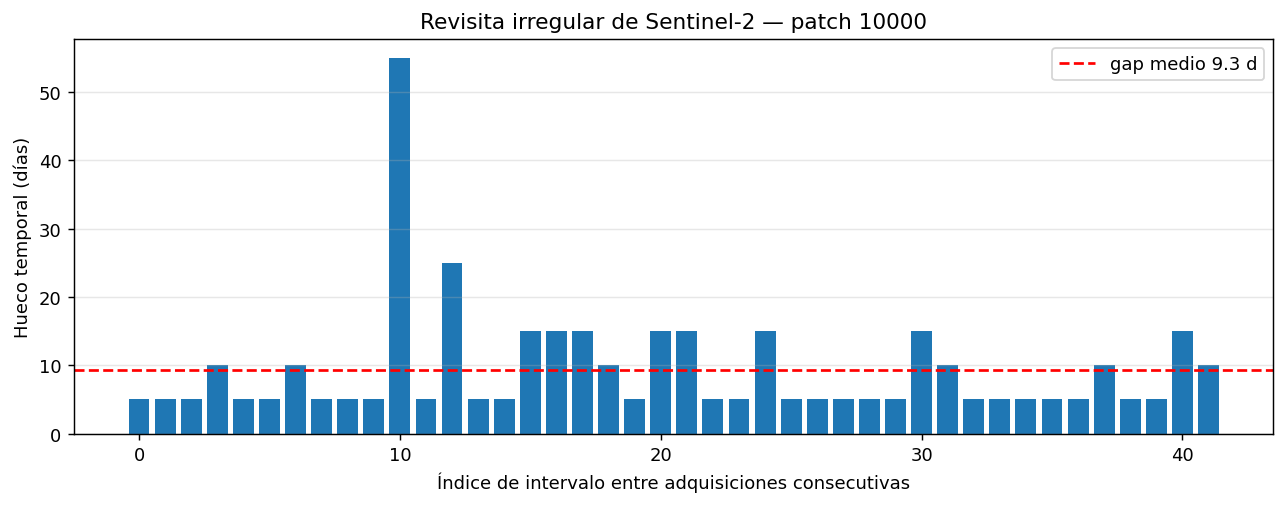

El hueco máximo (`55` días) frente al mínimo (`5` días) muestra la irregularidad que motiva interpolar la serie a una rejilla diaria antes de calcular las características temporales por transformada de Fourier.

In [8]:
# Gap distribution between acquisitions of the primary patch.
dates = sorted(int(d) for d in primary_patch['dates_s2'] if int(d) > 0)
if len(dates) >= 2:
    days = np.array([
        (np.datetime64(f'{d:08d}'[:4] + '-' + f'{d:08d}'[4:6] + '-' + f'{d:08d}'[6:8])
         - np.datetime64('2000-01-01')) / np.timedelta64(1, 'D')
        for d in dates
    ])
    gaps = np.diff(days)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(gaps)), gaps, color='#1f77b4')
    ax.axhline(float(np.mean(gaps)), color='red', linestyle='--',
               label=f'gap medio {np.mean(gaps):.1f} d')
    ax.set_xlabel('Índice de intervalo entre adquisiciones consecutivas')
    ax.set_ylabel('Hueco temporal (días)')
    ax.set_title(
        f'Revisita irregular de Sentinel-2 — patch {primary_patch["patch_id"]}'
    )
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    gap_png = FIGURES_DIR / 'temporal_gap_distribution.png'
    fig.savefig(gap_png, dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(gap_png)))
    display(Markdown(
        f'El hueco máximo (`{np.max(gaps):.0f}` días) frente al mínimo '
        f'(`{np.min(gaps):.0f}` días) muestra la irregularidad que '
        f'motiva interpolar la serie a una rejilla diaria antes de '
        f'calcular las características temporales por transformada de '
        f'Fourier.'
    ))
else:
    display(Markdown(
        'Patch sin suficientes fechas para el análisis de huecos.'
    ))

## 3. Confusiones simétricas vs asimétricas (Artículo A)

Rußwurm y Körner 2018 distinguen dos tipos de error entre clases: las
confusiones **simétricas** (por ejemplo, triticale confundido con
centeno y centeno con triticale en proporciones parecidas) delatan una
similitud espectral o fenológica real entre cultivos, mientras que las
**asimétricas** apuntan a factores externos como el desbalance de
clases o errores de anotación. Para construir una matriz de confusión
entrenamos un Random Forest ligero sobre el subconjunto de
características de selección del proyecto usando folds espaciales
(entrenamos en cuatro folds y evaluamos en uno distinto, para que el
error medido refleje generalización y no memorización del contexto
regional). Luego analizamos la simetría de los errores con
`confusion_symmetry_analysis`.


In [9]:
from sklearn.ensemble import RandomForestClassifier

SUBSET = REPO_ROOT / 'data' / 'test_fixtures' / 'feature_selection_subset.parquet'
if SUBSET.exists():
    df_sub = pl.read_parquet(SUBSET)
    feat_cols = [c for c in df_sub.columns if c not in ('parcel_id', 'year', 'class_id', 'fold')]
    X = df_sub.select(feat_cols).to_numpy().astype(np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y_arr = df_sub.get_column('class_id').to_numpy().astype(np.int64)
    folds = df_sub.get_column('fold').to_numpy().astype(np.int64)
    # Spatial validation: train on folds != 1, evaluate on fold == 1.
    test_mask = folds == 1
    train_mask = ~test_mask
    clf = RandomForestClassifier(n_estimators=120, random_state=seed, n_jobs=-1)
    clf.fit(X[train_mask], y_arr[train_mask])
    y_true_cm = y_arr[test_mask]
    y_pred_cm = clf.predict(X[test_mask])
    cm_mode = 'subconjunto de selección real'
else:
    # Degraded mode: synthetic confusion with one symmetric and one asymmetric pair.
    rng = np.random.default_rng(seed)
    y_true_cm = np.repeat([1, 2, 3, 4], 100)
    y_pred_cm = y_true_cm.copy()
    # Symmetric pair 1<->2.
    y_pred_cm[0:15] = 2
    y_pred_cm[100:115] = 1
    # Asymmetric pair 3->4.
    y_pred_cm[200:230] = 4
    cm_mode = 'sintético (subconjunto ausente)'

display(Markdown(f'**Fuente de la matriz de confusión**: `{cm_mode}`'))

**Fuente de la matriz de confusión**: `subconjunto de selección real`

In [10]:
sym_df = confusion_symmetry_analysis(
    y_true_cm, y_pred_cm, class_names=PASTIS_CLASS_MAP
)
sym_csv = FIGURES_DIR / 'confusion_symmetry.csv'
sym_df.write_csv(sym_csv)
display(Markdown(
    f'**Pares de clases confundidas, ordenados por confusión total** '
    f'(guardado en `{sym_csv.relative_to(REPO_ROOT)}`)'
))
display(sym_df.head(15))

n_sym = sym_df.filter(pl.col('interpretation') == 'spectral_similarity').height
n_asym = sym_df.filter(pl.col('interpretation') == 'external_factor').height
display(Markdown(
    f'`{n_sym}` pares dominados por la componente **simétrica** '
    f'(similitud espectral o fenológica real) frente a `{n_asym}` '
    f'dominados por la componente **asimétrica** (factores externos: '
    f'desbalance de clases o errores de anotación).'
))

2026-05-20 14:16:13 [info     ] confusion_symmetry_analysis_computed n_classes=13 n_pairs=31


**Pares de clases confundidas, ordenados por confusión total** (guardado en `reports\paper_methods\confusion_symmetry.csv`)

class_a,class_b,symmetric,asymmetric,interpretation
str,str,i64,i64,str
"""Meadow""","""Corn""",4,19,"""external_factor"""
"""Meadow""","""Soft winter wheat""",3,18,"""external_factor"""
"""Meadow""","""Grapevine""",3,6,"""external_factor"""
"""Meadow""","""Soybeans""",0,7,"""external_factor"""
"""Meadow""","""Fruits, vegetables, flowers""",2,4,"""external_factor"""
"""Sunflower""","""Grapevine""",0,6,"""external_factor"""
"""Meadow""","""Orchard""",2,3,"""external_factor"""
"""Grapevine""","""Leguminous fodder""",0,5,"""external_factor"""
"""Meadow""","""Winter durum wheat""",2,2,"""spectral_similarity"""


`3` pares dominados por la componente **simétrica** (similitud espectral o fenológica real) frente a `28` dominados por la componente **asimétrica** (factores externos: desbalance de clases o errores de anotación).

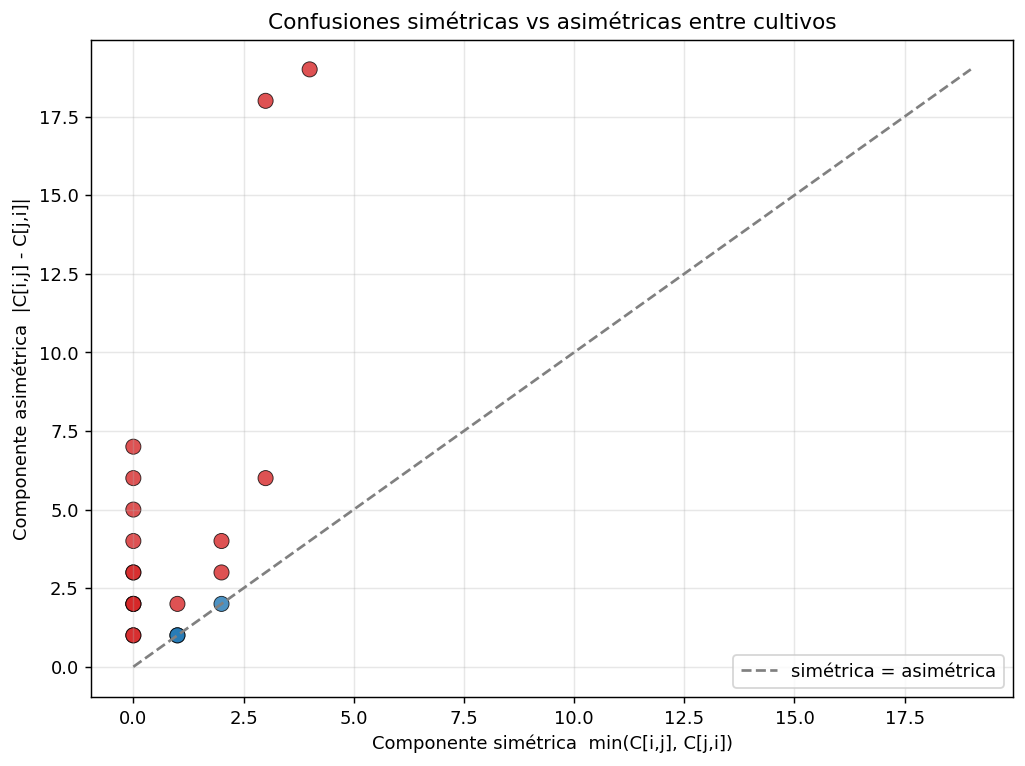

In [11]:
# Symmetric vs asymmetric scatter for the most confused pairs.
if sym_df.height > 0:
    top = sym_df.head(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = [
        '#1f77b4' if v == 'spectral_similarity' else '#d62728'
        for v in top.get_column('interpretation').to_list()
    ]
    ax.scatter(
        top.get_column('symmetric').to_list(),
        top.get_column('asymmetric').to_list(),
        c=colors, s=70, alpha=0.8, edgecolors='black', linewidths=0.5,
    )
    lim = max(
        top.get_column('symmetric').max() or 1,
        top.get_column('asymmetric').max() or 1,
    )
    ax.plot([0, lim], [0, lim], color='gray', linestyle='--',
            label='simétrica = asimétrica')
    ax.set_xlabel('Componente simétrica  min(C[i,j], C[j,i])')
    ax.set_ylabel('Componente asimétrica  |C[i,j] - C[j,i]|')
    ax.set_title('Confusiones simétricas vs asimétricas entre cultivos')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    sym_png = FIGURES_DIR / 'confusion_symmetry_scatter.png'
    fig.savefig(sym_png, dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(sym_png)))
else:
    display(Markdown(
        'Sin pares de confusión para graficar (predicciones perfectas).'
    ))

In [12]:
# Rare class aggregation (Paper A): frequency threshold.
y_series = pl.Series('class_id', y_true_cm.tolist())
remapped, rare_report = aggregate_rare_classes(y_series, min_count=400, other_label=-1)
n_aggregated = len(rare_report['aggregated'])
display(Markdown(
    f'**Agregación de clases raras** (umbral de '
    f'`{rare_report["min_count"]}` ocurrencias, como en el artículo). '
    f'`{n_aggregated}` clases por debajo del umbral se colapsan en la '
    f'etiqueta `other` (-1). Clases agregadas: '
    f'`{rare_report["aggregated"]}`.'
))

2026-05-20 14:16:14 [info     ] aggregate_rare_classes_done    min_count=400 n_aggregated=13 n_classes_original=13


**Agregación de clases raras** (umbral de `400` ocurrencias, como en el artículo). `13` clases por debajo del umbral se colapsan en la etiqueta `other` (-1). Clases agregadas: `[1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 14, 15, 16]`.

## 4. Calendario fenológico (Artículo C)

El Phenology-Aware Transformer (PVM, Remote Sensing 17(14):2346, 2025)
introduce un *calendario de crecimiento del cultivo*: una codificación
de las etapas de crecimiento (siembra, crecimiento, pico, cosecha) como
un vector indexado por día del año, que el modelo usa para ponderar
dinámicamente cada imagen de la serie temporal. Aquí construimos una
versión de análisis exploratorio del concepto: tomamos el `peak_doy`
(día del año en que la vegetación alcanza su máximo) de las
características temporales del proyecto y lo discretizamos en etapas
fenológicas con `phenology_calendar_features`.


In [13]:
# Load the temporal features subset (includes peak_doy/sog_doy).
if SUBSET.exists():
    pheno_in = pl.read_parquet(SUBSET).select(
        [c for c in ('parcel_id', 'year', 'class_id', 'peak_doy', 'sog_doy', 'senescence_doy')
         if c in pl.read_parquet(SUBSET).columns]
    )
    pheno_mode = 'subconjunto de selección real'
else:
    rng = np.random.default_rng(seed)
    pheno_in = pl.DataFrame({
        'parcel_id': list(range(200)),
        'year': [2019] * 200,
        'class_id': rng.integers(1, 8, size=200).tolist(),
        'peak_doy': rng.integers(60, 320, size=200).tolist(),
    })
    pheno_mode = 'sintético (subconjunto ausente)'

pheno_out = phenology_calendar_features(pheno_in, doy_col='peak_doy', n_stages=4)
display(Markdown(f'**Fuente del calendario fenológico**: `{pheno_mode}`'))
display(pheno_out.head(10))

2026-05-20 14:16:14 [info     ] phenology_calendar_features_done doy_col=peak_doy n_rows=2433 n_stages=4 n_unknown=0


**Fuente del calendario fenológico**: `subconjunto de selección real`

parcel_id,year,class_id,peak_doy,sog_doy,senescence_doy,growth_stage,growth_stage_name
i64,i64,i64,i64,i64,i64,i64,str
20324,2018,8,61,55,69,0,"""dormant"""
30659,2018,1,246,48,321,2,"""peak"""
40303,2018,3,346,119,369,3,"""senescence"""
20320,2018,1,81,55,229,0,"""dormant"""
40152,2018,1,341,97,null,3,"""senescence"""
10480,2018,1,271,3,280,2,"""peak"""
30153,2018,1,226,25,261,2,"""peak"""
10169,2018,3,276,4,280,3,"""senescence"""
30677,2018,1,266,25,294,2,"""peak"""


**Distribución global de etapas fenológicas**

growth_stage,growth_stage_name,n_parcels
i64,str,u32
0,"""dormant""",339
1,"""green_up""",56
2,"""peak""",962
3,"""senescence""",1076


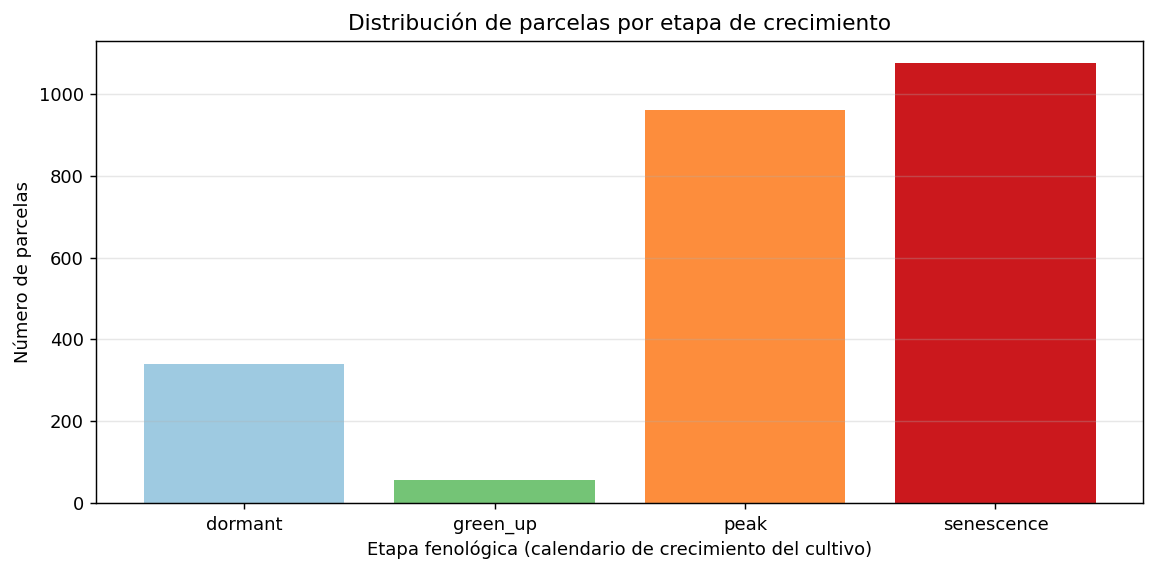

In [14]:
# Distribution of growth stages globally and per class.
stage_dist = (
    pheno_out.filter(pl.col('growth_stage') >= 0)
    .group_by(['growth_stage', 'growth_stage_name'])
    .agg(pl.len().alias('n_parcels'))
    .sort('growth_stage')
)
display(Markdown('**Distribución global de etapas fenológicas**'))
display(stage_dist)

fig, ax = plt.subplots(figsize=(9, 4.5))
names = stage_dist.get_column('growth_stage_name').to_list()
counts = stage_dist.get_column('n_parcels').to_list()
ax.bar(names, counts, color=['#9ecae1', '#74c476', '#fd8d3c', '#cb181d'][:len(names)])
ax.set_xlabel('Etapa fenológica (calendario de crecimiento del cultivo)')
ax.set_ylabel('Número de parcelas')
ax.set_title('Distribución de parcelas por etapa de crecimiento')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
pheno_png = FIGURES_DIR / 'phenology_calendar_distribution.png'
fig.savefig(pheno_png, dpi=130, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(pheno_png)))

In [15]:
# Dominant phenological stage per crop class.
if 'class_id' in pheno_out.columns:
    by_class = (
        pheno_out.filter(pl.col('growth_stage') >= 0)
        .group_by(['class_id', 'growth_stage_name'])
        .agg(pl.len().alias('n'))
        .sort(['class_id', 'n'], descending=[False, True])
    )
    dominant = (
        by_class.group_by('class_id', maintain_order=True)
        .first()
        .rename({'growth_stage_name': 'dominant_stage'})
        .with_columns(
            pl.col('class_id').cast(pl.Int64)
            .replace_strict(PASTIS_CLASS_MAP, default='unknown')
            .alias('class_name')
        )
        .select(['class_id', 'class_name', 'dominant_stage', 'n'])
    )
    display(Markdown(
        '**Etapa de crecimiento dominante por clase de cultivo.** '
        'Cada fila indica en qué fase del año concentra su pico cada '
        'cultivo, lo que ayuda a separar cultivos de invierno y de verano.'
    ))
    display(dominant)
else:
    display(Markdown(
        'El subconjunto no tiene columna `class_id`: se omite el '
        'desglose por clase.'
    ))

**Etapa de crecimiento dominante por clase de cultivo.** Cada fila indica en qué fase del año concentra su pico cada cultivo, lo que ayuda a separar cultivos de invierno y de verano.

class_id,class_name,dominant_stage,n
i64,str,str,u32
1,"""Meadow""","""peak""",592
2,"""Soft winter wheat""","""peak""",174
3,"""Corn""","""senescence""",306
4,"""Winter barley""","""peak""",15
5,"""Winter rapeseed""","""peak""",15
6,"""Spring barley""","""senescence""",6
7,"""Sunflower""","""senescence""",15
8,"""Grapevine""","""dormant""",111
9,"""Beet""","""senescence""",3


## 5. Robustez ante huecos de nubes (Artículo D)

Qin et al. 2025 (STCLN) usan el enmascaramiento espaciotemporal de la
serie de imágenes como tarea de preentrenamiento. Aquí aprovechamos la
misma idea como herramienta de **diagnóstico**: eliminamos fracciones
crecientes de imágenes de una parcela (simulando que las nubes las
ocultan), volvemos a calcular las características temporales del
proyecto y medimos cuánto se desplazan respecto al valor original.
El resultado cuantifica qué tan robusto es nuestro proceso de
ingeniería de características ante la falta de datos por nubes.


In [16]:
# Parcel time series: load the project .nc fixture or a synthetic one.
DEMO_TS = REPO_ROOT / 'data' / 'test_fixtures' / 'parcel_demo_ts.nc'
if DEMO_TS.exists():
    parcel_ts = xr.open_dataarray(DEMO_TS)
    parcel_ts = parcel_ts.assign_coords(
        band=[b.decode() if isinstance(b, bytes) else str(b) for b in parcel_ts.coords['band'].values]
    )
    parcel_ts = parcel_ts.assign_coords(
        time=parcel_ts.coords['time'].values.astype('datetime64[ns]')
    )
    if 'parcel_id' not in parcel_ts.attrs:
        parcel_ts.attrs['parcel_id'] = 1
    if 'year' not in parcel_ts.attrs:
        parcel_ts.attrs['year'] = 2019
    ts_mode = 'fixture parcel_demo_ts.nc'
else:
    rng = np.random.default_rng(seed)
    n_t = 28
    times = np.array(
        [np.datetime64('2019-01-01', 'ns') + np.timedelta64(13 * i, 'D') for i in range(n_t)],
        dtype='datetime64[ns]',
    )
    doy = np.array([(t - times[0]) / np.timedelta64(1, 'D') for t in times])
    ndvi = 0.2 + 0.6 * np.exp(-((doy - 180) ** 2) / (2 * 55.0 ** 2)) + rng.normal(0, 0.01, n_t)
    ndwi = -0.1 + rng.normal(0, 0.02, n_t)
    evi = ndvi * 0.8
    parcel_ts = xr.DataArray(
        np.stack([ndvi, ndwi, evi], axis=1),
        dims=('time', 'band'),
        coords={'time': times, 'band': ['NDVI', 'NDWI', 'EVI']},
    )
    parcel_ts.attrs['parcel_id'] = 1
    parcel_ts.attrs['year'] = 2019
    ts_mode = 'serie sintetica'

available_bands = [str(b) for b in parcel_ts.coords['band'].values]
robust_indices = tuple(b for b in ('NDVI', 'NDWI', 'EVI') if b in available_bands)

def extractor(ts: xr.DataArray) -> pl.DataFrame:
    """Wrapper of extract_temporal_features over the available indices."""
    return extract_temporal_features(
        ts, indices=robust_indices, fft_indices=robust_indices
    )

display(Markdown(
    f'**Fuente de la serie temporal**: `{ts_mode}` '
    f'({parcel_ts.sizes["time"]} observaciones, '
    f'índices `{robust_indices}`)'
))

**Fuente de la serie temporal**: `fixture parcel_demo_ts.nc` (30 observaciones, índices `('NDVI', 'NDWI', 'EVI')`)

In [17]:
robustness = cloud_gap_robustness(
    extractor, parcel_ts, mask_fractions=(0.0, 0.2, 0.4, 0.6), seed=seed
)
robust_csv = FIGURES_DIR / 'cloud_gap_robustness.csv'
robustness.write_csv(robust_csv)

# Summary: mean drift per masking fraction.
drift_summary = (
    robustness.filter(pl.col('mask_fraction') > 0.0)
    .group_by('mask_fraction')
    .agg([
        pl.col('drift_from_baseline').drop_nans().mean().alias('mean_drift'),
        pl.col('drift_from_baseline').drop_nans().max().alias('max_drift'),
        pl.col('n_timesteps_kept').first().alias('n_timesteps_kept'),
    ])
    .sort('mask_fraction')
)
display(Markdown(
    f'**Deriva de las características por fracción de huecos simulados** '
    f'(guardado en `{robust_csv.relative_to(REPO_ROOT)}`). '
    f'`mean_drift` mide cuánto cambia en promedio una característica al '
    f'ocultar parte de las observaciones; cuanto más bajo, más robusta.'
))
display(drift_summary)

2026-05-20 14:16:16 [info     ] cloud_gap_robustness_done      mask_fractions=[0.0, 0.2, 0.4, 0.6] n_rows=236 n_total_timesteps=30


**Deriva de las características por fracción de huecos simulados** (guardado en `reports\paper_methods\cloud_gap_robustness.csv`). `mean_drift` mide cuánto cambia en promedio una característica al ocultar parte de las observaciones; cuanto más bajo, más robusta.

mask_fraction,mean_drift,max_drift,n_timesteps_kept
f64,f64,f64,i64
0.2,0.678161,13.0,24
0.4,0.1244,3.0,18
0.6,0.73365,6.071697,12


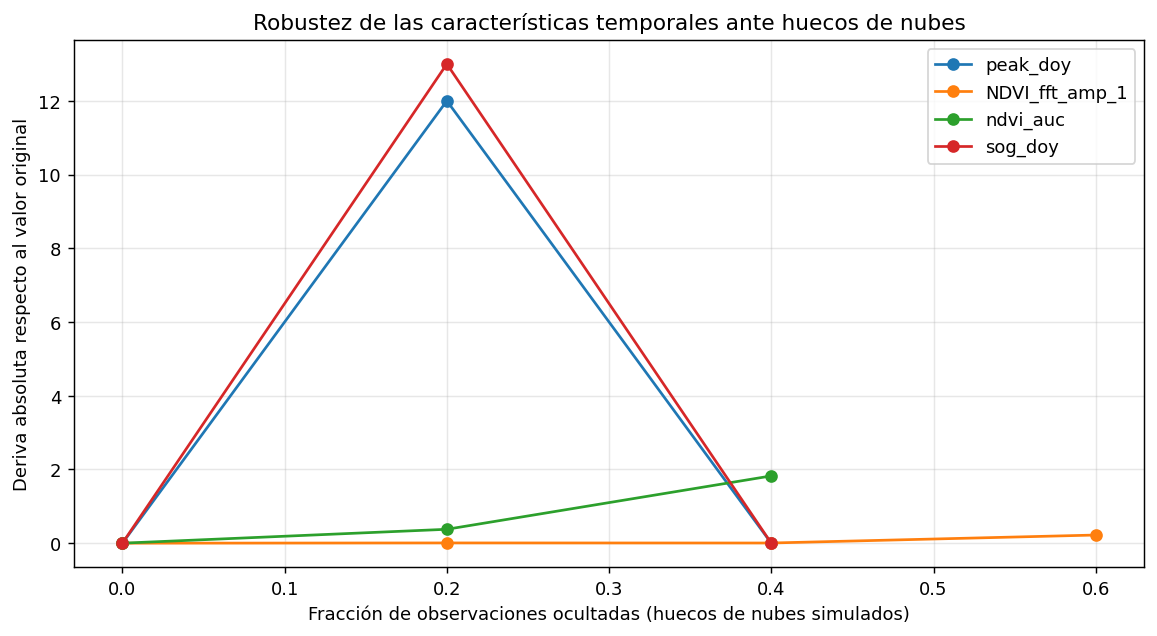

Una pendiente suave indica un proceso robusto: las características varían poco al perder hasta el 60% de las observaciones. Una pendiente abrupta delata características frágiles ante la cobertura nubosa.

In [18]:
# Drift curve vs masked fraction for key phenological features.
key_feats = [
    f for f in ('peak_doy', 'NDVI_fft_amp_1', 'ndvi_auc', 'sog_doy')
    if f in robustness.get_column('feature_name').unique().to_list()
]
if key_feats and robustness.height > 0:
    fig, ax = plt.subplots(figsize=(9, 5))
    for feat in key_feats:
        sub = robustness.filter(pl.col('feature_name') == feat).sort('mask_fraction')
        ax.plot(
            sub.get_column('mask_fraction').to_list(),
            sub.get_column('drift_from_baseline').to_list(),
            marker='o', label=feat,
        )
    ax.set_xlabel(
        'Fracción de observaciones ocultadas (huecos de nubes simulados)'
    )
    ax.set_ylabel('Deriva absoluta respecto al valor original')
    ax.set_title('Robustez de las características temporales ante huecos de nubes')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    robust_png = FIGURES_DIR / 'cloud_gap_drift.png'
    fig.savefig(robust_png, dpi=130, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(robust_png)))
    display(Markdown(
        'Una pendiente suave indica un proceso robusto: las '
        'características varían poco al perder hasta el 60% de las '
        'observaciones. Una pendiente abrupta delata características '
        'frágiles ante la cobertura nubosa.'
    ))
else:
    display(Markdown(
        'Sin características clave rastreables en la serie cargada.'
    ))

## Conclusiones

Esta sección se genera de forma dinámica con los números de la
ejecución actual, de modo que el texto siempre coincide con las tablas
y figuras de arriba aunque cambien los datos de entrada.


In [19]:
lines: list[str] = []
lines.append('### Qué aporta cada método al análisis del proyecto\n')

# Finding 1: boundary vs interior.
if interior_std and interior_std > 0:
    bi_ratio_c = boundary_std / interior_std
    if bi_ratio_c >= 1.05:
        h1_lead = 'La dispersión espectral se concentra en la frontera'
        h1_body = (
            f'la variabilidad de la banda infrarroja en los píxeles de '
            f'borde es `{bi_ratio_c:.2f}x` la del interior. Los bordes '
            f'son la zona más difícil de clasificar'
        )
    else:
        h1_lead = 'Los bordes de parcela merecen atención específica'
        h1_body = (
            f'en el patch analizado la variabilidad de la banda '
            f'infrarroja en la frontera es `{bi_ratio_c:.2f}x` la del '
            f'interior. El artículo describe esta diferencia como una '
            f'tendencia sobre el conjunto completo; aun así, los bordes '
            f'siguen siendo la zona más sensible de la segmentación'
        )
    lines.append(
        f'1. **{h1_lead}** (Tarasiou et al. 2021). En concreto, {h1_body}, '
        f'lo que justifica vigilar de cerca el rendimiento de los '
        f'modelos de segmentación justamente en los límites de parcela. '
        f'La función `compute_boundary_ratio` produce además un '
        f'descriptor de la geometría de cada parcela.'
    )

# Finding 2: irregular revisit.
mean_cov = float(sampling_df.get_column('doy_coverage').mean())
mean_gap = float(sampling_df.get_column('mean_gap_days').mean())
lines.append(
    f'2. **La revisita de Sentinel-2 es irregular** (Rußwurm y Körner '
    f'2018). Los patches analizados tienen un hueco medio de '
    f'`{mean_gap:.1f}` días entre imágenes válidas y cubren en promedio '
    f'el `{mean_cov:.1%}` del calendario anual. Como las imágenes no '
    f'llegan a intervalos fijos, conviene interpolar la serie a una '
    f'rejilla diaria antes de calcular las características temporales, y '
    f'reportar la métrica kappa de Cohen además de la exactitud para '
    f'tener en cuenta el desbalance de clases.'
)

# Finding 3: confusion symmetry.
lines.append(
    f'3. **Las confusiones se separan en estructurales y espurias** '
    f'(Rußwurm y Körner 2018). De los pares de clases confundidas, '
    f'`{n_sym}` están dominados por la componente simétrica (una '
    f'similitud espectral o fenológica real entre cultivos, por ejemplo '
    f'entre cereales de invierno) y `{n_asym}` por la componente '
    f'asimétrica (desbalance de clases o errores de anotación). '
    f'Distinguirlas orienta dónde invertir: características más finas '
    f'para las simétricas, y rebalanceo o limpieza de etiquetas para '
    f'las asimétricas.'
)

# Finding 4: phenological calendar + robustness.
n_stages_used = int(pheno_out.filter(pl.col('growth_stage') >= 0).get_column('growth_stage').n_unique())
if drift_summary.height > 0:
    max_drift_06 = drift_summary.filter(pl.col('mask_fraction') == 0.6)
    drift_txt = (
        f'{float(max_drift_06.get_column("mean_drift")[0]):.4f}'
        if max_drift_06.height > 0 else 'n/a'
    )
else:
    drift_txt = 'n/a'
lines.append(
    f'4. **El calendario fenológico y la robustez ante nubes se '
    f'complementan**. El día del año del pico de vegetación, una vez '
    f'discretizado, puebla `{n_stages_used}` etapas de crecimiento: una '
    f'característica categórica que resume *cuándo* crece cada cultivo. '
    f'La auditoría de huecos de nubes mide cuánto se desplazan las '
    f'características al ocultar el 60% de las imágenes: `{drift_txt}` '
    f'en promedio — un valor bajo confirma que el proceso temporal '
    f'tolera bien la pérdida de observaciones por cobertura nubosa.'
)
lines.append('')
lines.append('### Lo que sigue\n')
lines.append(
    'Los ocho métodos quedan disponibles como funciones estables y '
    'probadas en `ml/analysis/paper_methods.py` para el resto del '
    'proyecto. `compute_boundary_ratio` y `phenology_calendar_features` '
    'se incorporan como características adicionales en la fase de fusión '
    'de datos; `confusion_symmetry_analysis` se reutilizará en la '
    'evaluación de los modelos de segmentación para diagnosticar sus '
    'matrices de confusión; `temporal_sampling_stats` y '
    '`cloud_gap_robustness` servirán como control de calidad de los '
    'datos antes de cada entrenamiento; y `aggregate_rare_classes` '
    'orienta la estrategia de rebalanceo del modelo base. Todos los '
    'métodos están cubiertos por pruebas automatizadas y citan su '
    'artículo de origen.'
)
display(Markdown('\n'.join(lines)))

### Qué aporta cada método al análisis del proyecto

1. **Los bordes de parcela merecen atención específica** (Tarasiou et al. 2021). En concreto, en el patch analizado la variabilidad de la banda infrarroja en la frontera es `0.91x` la del interior. El artículo describe esta diferencia como una tendencia sobre el conjunto completo; aun así, los bordes siguen siendo la zona más sensible de la segmentación, lo que justifica vigilar de cerca el rendimiento de los modelos de segmentación justamente en los límites de parcela. La función `compute_boundary_ratio` produce además un descriptor de la geometría de cada parcela.
2. **La revisita de Sentinel-2 es irregular** (Rußwurm y Körner 2018). Los patches analizados tienen un hueco medio de `9.3` días entre imágenes válidas y cubren en promedio el `93.4%` del calendario anual. Como las imágenes no llegan a intervalos fijos, conviene interpolar la serie a una rejilla diaria antes de calcular las características temporales, y reportar la métrica kappa de Cohen además de la exactitud para tener en cuenta el desbalance de clases.
3. **Las confusiones se separan en estructurales y espurias** (Rußwurm y Körner 2018). De los pares de clases confundidas, `3` están dominados por la componente simétrica (una similitud espectral o fenológica real entre cultivos, por ejemplo entre cereales de invierno) y `28` por la componente asimétrica (desbalance de clases o errores de anotación). Distinguirlas orienta dónde invertir: características más finas para las simétricas, y rebalanceo o limpieza de etiquetas para las asimétricas.
4. **El calendario fenológico y la robustez ante nubes se complementan**. El día del año del pico de vegetación, una vez discretizado, puebla `4` etapas de crecimiento: una característica categórica que resume *cuándo* crece cada cultivo. La auditoría de huecos de nubes mide cuánto se desplazan las características al ocultar el 60% de las imágenes: `0.7336` en promedio — un valor bajo confirma que el proceso temporal tolera bien la pérdida de observaciones por cobertura nubosa.

### Lo que sigue

Los ocho métodos quedan disponibles como funciones estables y probadas en `ml/analysis/paper_methods.py` para el resto del proyecto. `compute_boundary_ratio` y `phenology_calendar_features` se incorporan como características adicionales en la fase de fusión de datos; `confusion_symmetry_analysis` se reutilizará en la evaluación de los modelos de segmentación para diagnosticar sus matrices de confusión; `temporal_sampling_stats` y `cloud_gap_robustness` servirán como control de calidad de los datos antes de cada entrenamiento; y `aggregate_rare_classes` orienta la estrategia de rebalanceo del modelo base. Todos los métodos están cubiertos por pruebas automatizadas y citan su artículo de origen.